### This notebook compute "P11. Slope of the glacier mass" indicator for the 27 basins of IKI Project

Spanish: Pendiente de la masa glaciar

**Created:** 6/23/2025 by Jorge Mayo (jmayo@rti.org)  

**Inputs:**   MAPA_NACIONAL_DE_ECOSISTEMAS_2012-2018 (MINAM), INAIGEM inventario de glaciares 2020 https://geocatmin.ingemmet.gob.pe/geocatmin/ 
 
**Assumptions:** Instead of finding the 'mode' slope as noted in the guide, we found the average slope of each glaciar. Then, they were associated scores and the median score was assigned for each COMID. COMIDs without a glacier are assigned NaN so the indicator is not included in the calculation. 

**N/A Handling:** NaN values in slope rasters are ignored when calculating mean slope. NaN set to 0 for slope classes.  
 
**Notes:**  Preprocessed the DEM in GIS to find the slope. We will need to make changes in this script if we get a future glaciers shapefile

General Methodology:  
Slope raster (DEM) and glacier polygons
1. For each glacier geometry, clip the slope raster data  and calculate the mean slope.  
2. Classify the slopes: Default is 0 and gets overwritten with 1 for slopes > 40, 0.75 for slopes from (20,40], 0.5 for slopes from (10,20]; and 0.25 for slopes < 10.  
3. Groups glacial slope categories by COMID and calculates the median value per COMID.  


In [1]:
import pandas as pd
import geopandas as gpd
import sqlite3
import matplotlib.pyplot as plt
from rasterstats import zonal_stats
import rasterio
from rasterio.mask import mask
import numpy as np
from scipy.stats import mode
import yaml
from pathlib import Path

In [2]:
# set master path for input data from config file

config_path = Path("../../config.yaml")

with open(config_path, "r") as f:
    config = yaml.safe_load(f)

master_path = Path(config["master_path"])

In [3]:
subbasins_shapefile = master_path / "Modelacion" / "Grupos_Modelacion" / "GIS_WaterALLOC_General" / "Peru_AHD_with_districts.shp"
db_path = master_path / "Indicadores" / "BD_RiesgoClimatico_IKI.db"
glaciares = master_path / "Indicadores" / "Datos_INAIGEM" / "Glaciares_2020_COMID_v2.shp"
glaciares_futuro = master_path / "Indicadores" / "Datos_INAIGEM" / "glaciares_2050_SSP585.shp"
Peru_slope = master_path / "Indicadores" / "Otros_GIS" / "peru_slope.tif"
Peru_dem = master_path / "Indicadores" / "Otros_GIS" / "peru_dem_clip.tif"

In [4]:
# set up indicator ID and get scenarios from database
IndID= 111 #Indicator ID (Exposure = 2 + 0X where X is the Exposure Indicator number, Peligro= 1 +0x, VSB= 3 +0x, VSS= 4 +0x, VCA= 5 +0x)
conn = sqlite3.connect(db_path)

scenarios_df = pd.read_sql_query(
    """
    SELECT ScnID, ScnName
    FROM ScnMod
    """,
    conn
)

conn.close()

scenario_ids = scenarios_df['ScnID'].tolist()

In [5]:
scenario_glacier_config = {
    1: {"use_future_glaciers": False},
    2: {"use_future_glaciers": True},
    3: {"use_future_glaciers": True},
}

In [6]:
# Load the shapefiles
subbasins_gdf = gpd.read_file(subbasins_shapefile).to_crs('EPSG:32718')
glaciares_actual_gdf = gpd.read_file(glaciares).to_crs('EPSG:32718')
glaciares_futuro_gdf = gpd.read_file(glaciares_futuro).to_crs("EPSG:32718")

In [7]:
with rasterio.open(Peru_slope) as src:
    slope_crs = src.crs
    print("Slope Raster CRS:", slope_crs)

print("Current Glacier CRS:", glaciares_actual_gdf.crs)
print("Future Glacier CRS:", glaciares_futuro_gdf.crs)

glaciares_actual_gdf = glaciares_actual_gdf.to_crs(slope_crs)
glaciares_futuro_gdf = glaciares_futuro_gdf.to_crs(slope_crs)

print("Reprojected Current Glacier CRS:", glaciares_actual_gdf.crs)
print("Reprojected Future Glacier CRS:", glaciares_futuro_gdf.crs)


Slope Raster CRS: EPSG:4326
Current Glacier CRS: EPSG:32718
Future Glacier CRS: EPSG:32718
Reprojected Current Glacier CRS: GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AXIS["Latitude",NORTH],AXIS["Longitude",EAST],AUTHORITY["EPSG","4326"]]
Reprojected Future Glacier CRS: GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AXIS["Latitude",NORTH],AXIS["Longitude",EAST],AUTHORITY["EPSG","4326"]]


In [8]:
def calculate_glacier_slope_values(glacier_gdf, slope_raster_path):
    glacier_gdf = glacier_gdf.copy()

    glacier_slope_values = []

    with rasterio.open(slope_raster_path) as src:

        for geom in glacier_gdf.geometry:

            try:
                out_image, out_transform = mask(src, [geom], crop=True)
                slope_clipped = out_image[0]

                slope_clipped = np.where(
                    slope_clipped == src.nodata,
                    np.nan,
                    slope_clipped
                )

                mean_slope = np.nanmean(slope_clipped)

            except Exception:
                mean_slope = np.nan

            glacier_slope_values.append(mean_slope)

    glacier_gdf["mean_slope"] = glacier_slope_values

    glacier_gdf["slope_value"] = np.nan

    glacier_gdf.loc[
        glacier_gdf["mean_slope"] > 40,
        "slope_value"
    ] = 1

    glacier_gdf.loc[
        (glacier_gdf["mean_slope"] <= 40) &
        (glacier_gdf["mean_slope"] > 20),
        "slope_value"
    ] = 0.75

    glacier_gdf.loc[
        (glacier_gdf["mean_slope"] <= 20) &
        (glacier_gdf["mean_slope"] > 10),
        "slope_value"
    ] = 0.5

    glacier_gdf.loc[
        glacier_gdf["mean_slope"] <= 10,
        "slope_value"
    ] = 0.25

    slope_by_comid = (
        glacier_gdf
        .groupby("COMID", as_index=False)
        .agg({"slope_value": "median"})
    )

    return glacier_gdf, slope_by_comid

In [9]:
# Baseline slope values from 2020 glacier inventory
glaciares_actual_with_slope, baseline_slope_df = calculate_glacier_slope_values(
    glacier_gdf=glaciares_actual_gdf,
    slope_raster_path=Peru_slope
)

baseline_slope_df = baseline_slope_df.rename(
    columns={"slope_value": "Baseline_slope_value"}
)

C:\Users\sbakar\AppData\Local\Temp\ipykernel_6312\3477836828.py:20: RuntimeWarning: Mean of empty slice
  mean_slope = np.nanmean(slope_clipped)
C:\Users\sbakar\AppData\Local\Temp\ipykernel_6312\3477836828.py:20: RuntimeWarning: Mean of empty slice
  mean_slope = np.nanmean(slope_clipped)
C:\Users\sbakar\AppData\Local\Temp\ipykernel_6312\3477836828.py:20: RuntimeWarning: Mean of empty slice
  mean_slope = np.nanmean(slope_clipped)
C:\Users\sbakar\AppData\Local\Temp\ipykernel_6312\3477836828.py:20: RuntimeWarning: Mean of empty slice
  mean_slope = np.nanmean(slope_clipped)
C:\Users\sbakar\AppData\Local\Temp\ipykernel_6312\3477836828.py:20: RuntimeWarning: Mean of empty slice
  mean_slope = np.nanmean(slope_clipped)
C:\Users\sbakar\AppData\Local\Temp\ipykernel_6312\3477836828.py:20: RuntimeWarning: Mean of empty slice
  mean_slope = np.nanmean(slope_clipped)
C:\Users\sbakar\AppData\Local\Temp\ipykernel_6312\3477836828.py:20: RuntimeWarning: Mean of empty slice
  mean_slope = np.nanmean(

In [10]:
# Future slope values from projected glacier inventory
glaciares_futuro_with_slope, future_slope_df = calculate_glacier_slope_values(
    glacier_gdf=glaciares_futuro_gdf,
    slope_raster_path=Peru_slope
)

future_slope_df = future_slope_df.rename(
    columns={"slope_value": "Future_slope_value"}
)

C:\Users\sbakar\AppData\Local\Temp\ipykernel_6312\3477836828.py:20: RuntimeWarning: Mean of empty slice
  mean_slope = np.nanmean(slope_clipped)
C:\Users\sbakar\AppData\Local\Temp\ipykernel_6312\3477836828.py:20: RuntimeWarning: Mean of empty slice
  mean_slope = np.nanmean(slope_clipped)
C:\Users\sbakar\AppData\Local\Temp\ipykernel_6312\3477836828.py:20: RuntimeWarning: Mean of empty slice
  mean_slope = np.nanmean(slope_clipped)
C:\Users\sbakar\AppData\Local\Temp\ipykernel_6312\3477836828.py:20: RuntimeWarning: Mean of empty slice
  mean_slope = np.nanmean(slope_clipped)
C:\Users\sbakar\AppData\Local\Temp\ipykernel_6312\3477836828.py:20: RuntimeWarning: Mean of empty slice
  mean_slope = np.nanmean(slope_clipped)
C:\Users\sbakar\AppData\Local\Temp\ipykernel_6312\3477836828.py:20: RuntimeWarning: Mean of empty slice
  mean_slope = np.nanmean(slope_clipped)
C:\Users\sbakar\AppData\Local\Temp\ipykernel_6312\3477836828.py:20: RuntimeWarning: Mean of empty slice
  mean_slope = np.nanmean(

In [11]:
# Merge baseline and future values back to all subbasins
subbasins_with_slope = subbasins_gdf.merge(
    baseline_slope_df,
    on="COMID",
    how="left"
)

subbasins_with_slope = subbasins_with_slope.merge(
    future_slope_df,
    on="COMID",
    how="left"
)

future_projection_comids = set(
    glaciares_futuro_gdf["COMID"]
    .dropna()
    .unique()
)

subbasins_with_slope["Has_Future_Projection"] = (
    subbasins_with_slope["COMID"].isin(future_projection_comids)
)

print("Baseline slope score distribution:")
print(
    subbasins_with_slope["Baseline_slope_value"]
    .value_counts(dropna=False)
    .sort_index()
)

print("\nFuture slope score distribution:")
print(
    subbasins_with_slope["Future_slope_value"]
    .value_counts(dropna=False)
    .sort_index()
)

print("\nCOMIDs with future glacier projection:")
print(subbasins_with_slope["Has_Future_Projection"].sum())

Baseline slope score distribution:
Baseline_slope_value
0.250       2
0.500      49
0.625      16
0.750     217
NaN      3371
Name: count, dtype: int64

Future slope score distribution:
Future_slope_value
0.50       9
0.75      40
1.00       2
NaN     3604
Name: count, dtype: int64

COMIDs with future glacier projection:
52


array([[<Axes: title={'center': 'mean_slope'}>]], dtype=object)

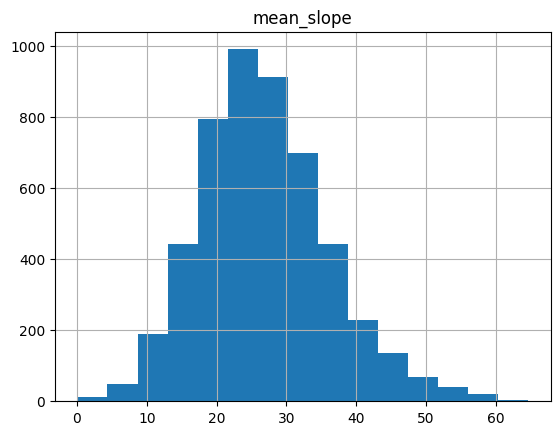

In [12]:
glaciares_actual_with_slope.hist(column="mean_slope", bins=15)

<Axes: >

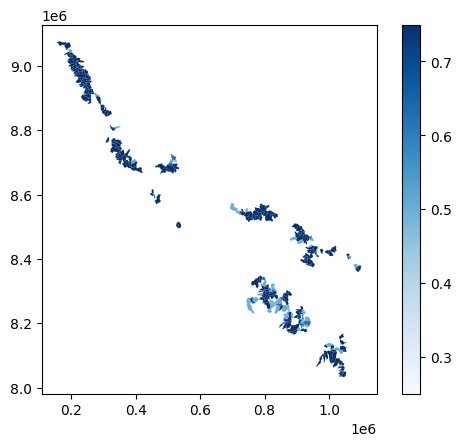

In [13]:
subbasins_with_slope.plot(
    column="Baseline_slope_value",
    cmap="Blues",
    legend=True
)


<Axes: >

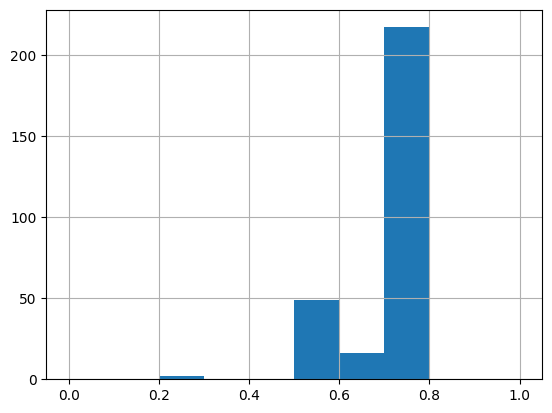

In [14]:
subbasins_with_slope["Baseline_slope_value"].hist(
    bins=10,
    range=(0, 1)
)

In [15]:
conn = sqlite3.connect(db_path)
cursor = conn.cursor()

rows_to_insert = []

for scn_id in scenario_ids:

    cfg = scenario_glacier_config.get(
        scn_id,
        {"use_future_glaciers": False}
    )

    scenario_df = subbasins_with_slope.copy()

    scenario_df["Value"] = scenario_df["Baseline_slope_value"]

    if cfg["use_future_glaciers"]:

        mask_future_projected = scenario_df["Has_Future_Projection"]

        scenario_df.loc[
            mask_future_projected,
            "Value"
        ] = scenario_df.loc[
            mask_future_projected,
            "Future_slope_value"
        ]

    for _, row in scenario_df.iterrows():

        rows_to_insert.append((
            scn_id,
            IndID,
            int(row["COMID"]),
            None if pd.isna(row["Value"]) else float(row["Value"])
        ))

insert_query = """
INSERT OR REPLACE INTO IndValues_Dyn (ScnID, IndID, COMID, Value)
VALUES (?, ?, ?, ?);
"""


In [16]:
indicator_limits = pd.read_sql_query(
    """
    SELECT IndID, Min, Max
    FROM Indicators
    WHERE IndID = ?
    """,
    conn,
    params=(IndID,)
)

if indicator_limits.empty:
    raise ValueError(f"No entry found in Indicators table for IndID = {IndID}")

ind_min = indicator_limits.loc[0, "Min"]
ind_max = indicator_limits.loc[0, "Max"]

print(f"Indicator {IndID}  Min: {ind_min}, Max: {ind_max}")

df_check = pd.DataFrame(
    rows_to_insert,
    columns=["ScnID", "IndID", "COMID", "Value"]
)

value_stats_by_scenario = (
    df_check
    .groupby("ScnID")["Value"]
    .agg(["min", "max", "count"])
    .reset_index()
    .merge(scenarios_df, on="ScnID", how="left")
)

value_stats_by_scenario["Indicator_Min"] = ind_min
value_stats_by_scenario["Indicator_Max"] = ind_max

print("\n=== Values to be inserted by scenario ===")
print(
    value_stats_by_scenario[
        [
            "ScnID",
            "ScnName",
            "min",
            "max",
            "count",
            "Indicator_Min",
            "Indicator_Max"
        ]
    ]
)

duplicates = df_check.duplicated(
    subset=["ScnID", "IndID", "COMID"]
)

print("\nDuplicates in rows_to_insert:")
print(df_check[duplicates])

Indicator 111  Min: 0, Max: 1

=== Values to be inserted by scenario ===
   ScnID      ScnName   min   max  count  Indicator_Min  Indicator_Max
0      1   Linea Base  0.25  0.75    284              0              1
1      2  CC CMIP6 85  0.25  1.00    284              0              1
2      3  CC CMIP6 45  0.25  1.00    284              0              1

Duplicates in rows_to_insert:
Empty DataFrame
Columns: [ScnID, IndID, COMID, Value]
Index: []


In [17]:
#Execute insert to SQLite Database
cursor.executemany(insert_query, rows_to_insert)
conn.commit()
conn.close()